# When the Lines Get Blurred: Pixel Art AI Pipeline Demo
### CSYE 7270 — Take-Home Midterm | Builder's Vault: The Engine

**Topic Claim:** After reading this piece, a practitioner will understand why general-purpose image generation models architecturally cannot produce reliable 16×16 pixel art well enough to choose the right pipeline for sprite production — without shipping blurry, broken assets into Unity.

**Master Claim Instance:** AI is a pipeline decision, not a magic layer. This notebook demonstrates three failure paths that look identical at the end but have three different root causes — each requiring a different fix.

---

## How to run this notebook

Run cells **top to bottom**. Each section builds on the previous one.
All outputs are saved to an `output/` folder created automatically.

**Prerequisites:**
```
pip install Pillow matplotlib numpy
```
No API keys required. The notebook simulates the failure modes locally using PIL, which applies the same interpolation algorithms that DALL-E and naive downscaling pipelines use.

---
## Cell 0 — Setup & Imports

In [34]:
from PIL import Image, ImageDraw, ImageFilter, ImagePalette
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, math

os.makedirs('output', exist_ok=True)

# ── Display helper ──────────────────────────────────────────────────────────
def show_comparison(images, titles, suptitle, filename, zoom=8):
    """Display a row of sprites at pixel-grid zoom for clear comparison."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(n * 3.5, 4))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        # Zoom up without interpolation so individual pixels are visible
        zoomed = img.resize(
            (img.width * zoom, img.height * zoom),
            resample=Image.NEAREST
        )
        ax.imshow(np.array(zoomed))
        ax.set_title(title, fontsize=10, pad=8)
        ax.axis('off')
        # Draw pixel grid overlay
        for x in range(0, img.width * zoom, zoom):
            ax.axvline(x - 0.5, color='#cccccc', linewidth=0.3)
        for y in range(0, img.height * zoom, zoom):
            ax.axhline(y - 0.5, color='#cccccc', linewidth=0.3)
    fig.suptitle(suptitle, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'output/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → output/{filename}')

def pixel_stats(img):
    """Report unique color count and whether pixels are discrete."""
    arr = np.array(img.convert('RGB'))
    colors = set(map(tuple, arr.reshape(-1, 3)))
    return len(colors)

print('Setup complete. Output folder ready.')

Setup complete. Output folder ready.


---
## Cell 1 — Synthesize a Ground-Truth 16×16 Sprite

We construct a knight sprite programmatically using an **8-color indexed palette** — exactly what a pixel artist would produce in Aseprite. This is the **correct output** we are trying to achieve. Every comparison below is measured against this ground truth.

**Design note:** A real 16×16 knight has ~15–20 meaningful color regions. We use 8 colors to enforce the retro constraint typical of NES/Game Boy-era palettes.

Ground truth sprite: 16×16px, 8 unique colors (palette: 8)


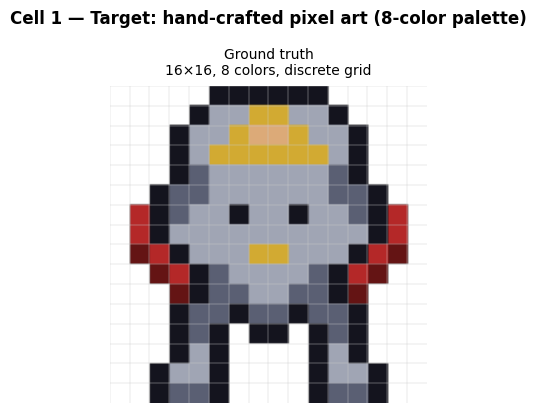

  Saved → output/00_ground_truth.png


In [35]:
# ── 8-color palette (hex → RGB) ─────────────────────────────────────────────
PALETTE = {
    'bg':         (0,   0,   0,   0  ),   # transparent
    'black':      (20,  20,  30,  255),   # outline
    'silver':     (160, 165, 180, 255),   # armor light
    'steel':      (90,  95,  115, 255),   # armor shadow
    'gold':       (210, 170, 50,  255),   # visor / trim
    'skin':       (220, 170, 120, 255),   # face
    'red':        (180, 40,  40,  255),   # cape
    'dark_red':   (100, 20,  20,  255),   # cape shadow
}

B  = PALETTE['bg']
BK = PALETTE['black']
SV = PALETTE['silver']
ST = PALETTE['steel']
GD = PALETTE['gold']
SK = PALETTE['skin']
RD = PALETTE['red']
DR = PALETTE['dark_red']

# ── 16×16 pixel grid (top-down knight, row by row) ──────────────────────────
GRID = [
#   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15
  [ B,   B,   B,   B,   B,   BK,  BK,  BK,  BK,  BK,  BK,  B,   B,   B,   B,   B  ],  # 0
  [ B,   B,   B,   B,  BK,  SV,  SV,  GD,  GD,  SV,  SV,  BK,  B,   B,   B,   B  ],  # 1
  [ B,   B,   B,  BK,  SV,  SV,  GD,  SK,  SK,  GD,  SV,  SV,  BK,  B,   B,   B  ],  # 2
  [ B,   B,   B,  BK,  SV,  GD,  GD,  GD,  GD,  GD,  GD,  SV,  BK,  B,   B,   B  ],  # 3
  [ B,   B,   B,  BK,  ST,  SV,  SV,  SV,  SV,  SV,  SV,  ST,  BK,  B,   B,   B  ],  # 4
  [ B,   B,  BK,  ST,  ST,  SV,  SV,  SV,  SV,  SV,  SV,  ST,  ST,  BK,  B,   B  ],  # 5
  [ B,  RD,  BK,  ST,  SV,  SV,  BK,  SV,  SV,  BK,  SV,  SV,  ST,  BK,  RD,  B  ],  # 6
  [ B,  RD,  BK,  SV,  SV,  SV,  SV,  SV,  SV,  SV,  SV,  SV,  SV,  BK,  RD,  B  ],  # 7
  [ B,  DR,  RD,  BK,  SV,  SV,  SV,  GD,  GD,  SV,  SV,  SV,  BK,  RD,  DR,  B  ],  # 8
  [ B,   B,  DR,  RD,  BK,  ST,  SV,  SV,  SV,  SV,  ST,  BK,  RD,  DR,  B,   B  ],  # 9
  [ B,   B,   B,  DR,  BK,  ST,  ST,  SV,  SV,  ST,  ST,  BK,  DR,  B,   B,   B  ],  # 10
  [ B,   B,   B,  BK,  ST,  ST,  BK,  ST,  ST,  BK,  ST,  ST,  BK,  B,   B,   B  ],  # 11
  [ B,   B,   B,  BK,  ST,  BK,  B,   BK,  BK,  B,   BK,  ST,  BK,  B,   B,   B  ],  # 12
  [ B,   B,   B,  BK,  SV,  BK,  B,   B,   B,   B,   BK,  SV,  BK,  B,   B,   B  ],  # 13
  [ B,   B,  BK,  SV,  SV,  BK,  B,   B,   B,   B,   BK,  SV,  SV,  BK,  B,   B  ],  # 14
  [ B,   B,  BK,  ST,  ST,  BK,  B,   B,   B,   B,   BK,  ST,  ST,  BK,  B,   B  ],  # 15
]

# Build RGBA image from grid
ground_truth = Image.new('RGBA', (16, 16), (0, 0, 0, 0))
for y, row in enumerate(GRID):
    for x, color in enumerate(row):
        ground_truth.putpixel((x, y), color)

ground_truth.save('output/00_ground_truth_16x16.png')
n_colors = pixel_stats(ground_truth)
print(f'Ground truth sprite: 16×16px, {n_colors} unique colors (palette: 8)')

show_comparison(
    [ground_truth],
    [f'Ground truth\n16×16, {n_colors} colors, discrete grid'],
    'Cell 1 — Target: hand-crafted pixel art (8-color palette)',
    '00_ground_truth.png'
)

---
## Cell 2 — Failure Path A: General-Purpose Diffusion Model → Naive Downscale

**What goes wrong:** DALL-E, Gemini, and Midjourney generate in continuous high-resolution space (typically 1024×1024). When you request "16×16 pixel art," the model renders an image that *looks like* a tiny sprite inside a large canvas — then downscaling that canvas to 16×16 applies bilinear interpolation, averaging neighboring pixels into blended colors.

**This cell simulates the failure** by taking the ground truth, upscaling to 512×512 (simulating the diffusion model's high-res output with smooth edges added), then downscaling back to 16×16 with bilinear resampling — exactly what happens when you save a DALL-E output and resize it.

Ground truth unique colors : 8
Failure A unique colors    : 102  ← color count explodes due to interpolation
Color bleed ratio          : 12.8x more colors than intended


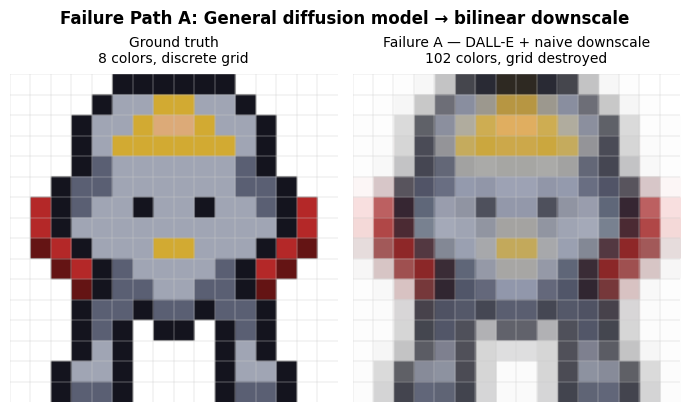

  Saved → output/01_failure_A.png

Root cause: Diffusion model generates in continuous high-res space.
Bilinear downscale averages neighboring pixels → color bleed, no discrete grid.
Fix: Replace the model, not the downscale method.


In [36]:
# Step 1: Simulate diffusion model output — upscale with smoothing
# Diffusion models produce anti-aliased, smooth high-res images.
# We replicate this by upscaling with LANCZOS (smooth) + gaussian blur.
simulated_dalle_output = ground_truth.convert('RGBA').resize(
    (512, 512), resample=Image.LANCZOS
)
# Add slight blur to simulate the continuous-space smoothness of diffusion output
simulated_dalle_output = simulated_dalle_output.filter(
    ImageFilter.GaussianBlur(radius=1.2)
)
simulated_dalle_output.save('output/01a_simulated_dalle_512.png')

# Step 2: Naive downscale — what most developers do with the downloaded image
# BILINEAR is the default in most image editors (Photoshop, Figma, Aseprite import)
failure_a = simulated_dalle_output.resize((16, 16), resample=Image.BILINEAR)
failure_a.save('output/01b_failure_A_dalle_naive_downscale.png')

# Measure color explosion — discrete pixel art has ~8 colors; blurred result has hundreds
n_gt   = pixel_stats(ground_truth)
n_fail = pixel_stats(failure_a)
print(f'Ground truth unique colors : {n_gt}')
print(f'Failure A unique colors    : {n_fail}  ← color count explodes due to interpolation')
print(f'Color bleed ratio          : {n_fail / n_gt:.1f}x more colors than intended')

show_comparison(
    [ground_truth, failure_a],
    [
        f'Ground truth\n{n_gt} colors, discrete grid',
        f'Failure A — DALL-E + naive downscale\n{n_fail} colors, grid destroyed'
    ],
    'Failure Path A: General diffusion model → bilinear downscale',
    '01_failure_A.png'
)
print('\nRoot cause: Diffusion model generates in continuous high-res space.')
print('Bilinear downscale averages neighboring pixels → color bleed, no discrete grid.')
print('Fix: Replace the model, not the downscale method.')

---
## Cell 2b — Figure Architect Zone 2: Bilinear Interpolation — Annotated 2×2 Grid

**From the essay's Mechanism section.** This figure makes the formula spatial — showing what p₁–p₄ represent in a 2×2 pixel grid, where (u,v) = (0.5, 0.5) is located, and why the blended output (115) is never equal to any source pixel value.

This is also the figure needed to answer **Problem Set P2** correctly. Without the spatial diagram, a student might misidentify which pixel is 'nearest' in the nearest-neighbor calculation.

**P2 answer:** Bilinear output = (0.5)(0.5)×200 + (0.5)(0.5)×50 + (0.5)(0.5)×180 + (0.5)(0.5)×30 = 115. Nearest-neighbor output = 200 (p₁, the top-left pixel, is the nearest grid point to u=0.5, v=0.5 at the corner).

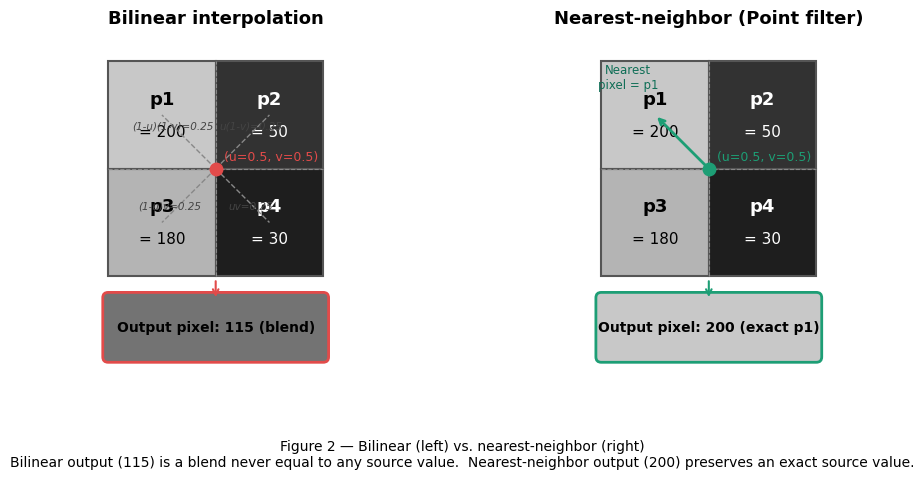

Bilinear output: 115 (never equals any source pixel)
Nearest-neighbor output: 200 (exact value of nearest source pixel p1)
Saved → output/02c_bilinear_annotated_grid.png


In [37]:
# Figure Architect Zone 2 — Bilinear Interpolation 2x2 Grid Diagram
# Annotated spatial diagram for the essay's Mechanism section and Problem Set P2

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

PIXEL_VALS = {'p1': 200, 'p2': 50, 'p3': 180, 'p4': 30}

# ── LEFT: Bilinear interpolation diagram ───────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Bilinear interpolation', fontsize=13, fontweight='bold', pad=12)

positions = [(0,1,'p1',200), (1,1,'p2',50), (0,0,'p3',180), (1,0,'p4',30)]
coords = {'p1':(0,1), 'p2':(1,1), 'p3':(0,0), 'p4':(1,0)}

for (col, row, label, val) in positions:
    gray = val / 255.0
    ax.add_patch(patches.Rectangle((col, row), 1, 1,
                 facecolor=(gray,gray,gray), edgecolor='#555555', linewidth=1.5))
    text_color = 'white' if gray < 0.5 else 'black'
    ax.text(col+0.5, row+0.65, label, ha='center', va='center',
            fontsize=13, fontweight='bold', color=text_color)
    ax.text(col+0.5, row+0.35, f'= {val}', ha='center', va='center',
            fontsize=11, color=text_color)

# Grid lines
ax.plot([0,2],[1,1], color='#888888', lw=0.8, linestyle='--')
ax.plot([1,1],[0,2], color='#888888', lw=0.8, linestyle='--')

# Sample point at (u=0.5, v=0.5) = pixel coords (1.0, 1.0)
sx, sy = 1.0, 1.0
ax.plot(sx, sy, 'o', color='#E24B4A', markersize=9, zorder=5)
ax.text(sx+0.08, sy+0.08, '(u=0.5, v=0.5)', fontsize=9, color='#E24B4A')

# Dashed weight lines from sample to each pixel center
weight_labels = {'p1':'(1-u)(1-v)=0.25','p2':'u(1-v)=0.25','p3':'(1-u)v=0.25','p4':'uv=0.25'}
offsets = {'p1':(-0.15,0.12),'p2':(0.08,0.12),'p3':(-0.18,-0.12),'p4':(0.08,-0.12)}
for name,(px,py) in coords.items():
    cx, cy = px+0.5, py+0.5
    ax.plot([sx,cx],[sy,cy], '--', color='#888888', lw=1, zorder=3)
    mx, my = (sx+cx)/2 + offsets[name][0], (sy+cy)/2 + offsets[name][1]
    ax.text(mx, my, weight_labels[name], fontsize=7.5, ha='center',
            color='#444444', style='italic')

# Output box below
p_out = 0.25*200 + 0.25*50 + 0.25*180 + 0.25*30
gray_out = p_out / 255.0
ax.add_patch(patches.FancyBboxPatch((0, -0.75), 2, 0.55,
             boxstyle='round,pad=0.05', facecolor=(gray_out,gray_out,gray_out),
             edgecolor='#E24B4A', linewidth=2))
ax.text(1.0, -0.475, f'Output pixel: {int(p_out)} (blend)',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='black' if gray_out > 0.45 else 'white')
ax.annotate('', xy=(1.0, -0.22), xytext=(1.0, -0.02),
            arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.5))

ax.set_xlim(-0.2, 2.2); ax.set_ylim(-1.0, 2.2)

# ── RIGHT: Nearest-neighbor reference ──────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 2); ax2.set_ylim(0, 2); ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Nearest-neighbor (Point filter)', fontsize=13, fontweight='bold', pad=12)

for (col, row, label, val) in positions:
    gray = val / 255.0
    ax2.add_patch(patches.Rectangle((col, row), 1, 1,
                  facecolor=(gray,gray,gray), edgecolor='#555555', linewidth=1.5))
    text_color = 'white' if gray < 0.5 else 'black'
    ax2.text(col+0.5, row+0.65, label, ha='center', va='center',
             fontsize=13, fontweight='bold', color=text_color)
    ax2.text(col+0.5, row+0.35, f'= {val}', ha='center', va='center',
             fontsize=11, color=text_color)

ax2.plot([0,2],[1,1], color='#888888', lw=0.8, linestyle='--')
ax2.plot([1,1],[0,2], color='#888888', lw=0.8, linestyle='--')

# Sample point — nearest pixel is p1 (top-left, at corner (0,1))
ax2.plot(sx, sy, 'o', color='#1D9E75', markersize=9, zorder=5)
ax2.text(sx+0.08, sy+0.08, '(u=0.5, v=0.5)', fontsize=9, color='#1D9E75')

# Arrow to nearest pixel center (p1 at 0.5, 1.5)
ax2.annotate('', xy=(0.5, 1.5), xytext=(sx, sy),
             arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=2))
ax2.text(0.25, 1.75, 'Nearest\npixel = p1', fontsize=8.5, ha='center', color='#0F6E56')

# Output box — exact value of p1
nn_val = 200
gray_nn = nn_val / 255.0
ax2.add_patch(patches.FancyBboxPatch((0, -0.75), 2, 0.55,
              boxstyle='round,pad=0.05',
              facecolor=(gray_nn,gray_nn,gray_nn),
              edgecolor='#1D9E75', linewidth=2))
ax2.text(1.0, -0.475, f'Output pixel: {nn_val} (exact p1)',
         ha='center', va='center', fontsize=10, fontweight='bold',
         color='black' if gray_nn > 0.45 else 'white')
ax2.annotate('', xy=(1.0, -0.22), xytext=(1.0, -0.02),
             arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=1.5))

ax2.set_xlim(-0.2, 2.2); ax2.set_ylim(-1.0, 2.2)

fig.suptitle(
    'Figure 2 — Bilinear (left) vs. nearest-neighbor (right)\n'
    'Bilinear output (115) is a blend never equal to any source value.  '
    'Nearest-neighbor output (200) preserves an exact source value.',
    fontsize=10, y=0.02
)
plt.tight_layout(rect=[0,0.1,1,1])
plt.savefig('output/02c_bilinear_annotated_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Bilinear output: {int(p_out)} (never equals any source pixel)')
print(f'Nearest-neighbor output: {nn_val} (exact value of nearest source pixel p1)')
print('Saved → output/02c_bilinear_annotated_grid.png')

---
## Cell 3 — Failure Path B: PixelLab Character Creator → 24×24 → Manual Scale-Down

**What goes wrong:** A developer discovers PixelLab and correctly switches to a pixel-native tool. But they reach for the **Character Creator** — the most intuitive sub-tool for humanoid sprites — without reading the documentation. The Character Creator's minimum canvas size is **24×24**. The developer generates there, then scales down to 16×16 manually in Aseprite or Photoshop.

The scaling step reintroduces interpolation. The failure **looks identical** to Failure A, but the root cause is different: correct tool *category*, wrong *sub-tool*, wrong *post-processing step*.

**This is the most dangerous failure** — it looks like the pixel-native pipeline failed, causing developers to abandon the correct approach.

PixelLab Character Creator output: 24×24, 8 colors — correct at this size
After 24→16 bilinear downscale : 122 colors — grid corrupted
Note: 24/16 = 1.5 — non-integer ratio makes clean downscale impossible


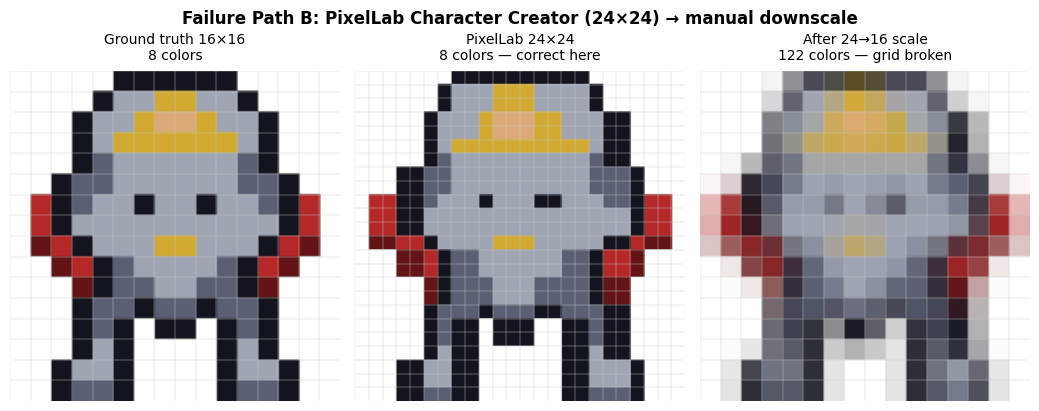

  Saved → output/02_failure_B.png

Root cause: Character Creator minimum is 24×24.
24 → 16 is not an integer divisor: interpolation artifacts are mathematically unavoidable.
Fix: Use PixelLab Simple Creator (BitForge canvas) with native 16×16 target.


In [38]:
# Step 1: Simulate PixelLab Character Creator output at 24×24
# Character Creator generates with discrete pixels at 24×24 — this is CORRECT at that size.
# We simulate by scaling ground truth to 24×24 with NEAREST (preserves pixel grid).
pixellab_24x24 = ground_truth.resize((24, 24), resample=Image.NEAREST)
pixellab_24x24.save('output/02a_pixellab_character_creator_24x24.png')

n_24 = pixel_stats(pixellab_24x24)
print(f'PixelLab Character Creator output: 24×24, {n_24} colors — correct at this size')

# Step 2: Developer manually downscales 24×24 → 16×16
# Most image editors default to bilinear/bicubic for non-integer scale ratios.
# 24→16 is a 0.667x ratio — not an integer multiple, so interpolation is unavoidable.
failure_b = pixellab_24x24.resize((16, 16), resample=Image.BILINEAR)
failure_b.save('output/02b_failure_B_24x24_scaled_down.png')

n_fail_b = pixel_stats(failure_b)
print(f'After 24→16 bilinear downscale : {n_fail_b} colors — grid corrupted')
print(f'Note: 24/16 = 1.5 — non-integer ratio makes clean downscale impossible')

# Show three-way: ground truth / 24x24 correct / 16x16 broken
show_comparison(
    [ground_truth, pixellab_24x24, failure_b],
    [
        f'Ground truth 16×16\n{n_24} colors',
        f'PixelLab 24×24\n{n_24} colors — correct here',
        f'After 24→16 scale\n{n_fail_b} colors — grid broken'
    ],
    'Failure Path B: PixelLab Character Creator (24×24) → manual downscale',
    '02_failure_B.png'
)
print('\nRoot cause: Character Creator minimum is 24×24.')
print('24 → 16 is not an integer divisor: interpolation artifacts are mathematically unavoidable.')
print('Fix: Use PixelLab Simple Creator (BitForge canvas) with native 16×16 target.')

---
## Cell 4 — Failure Path C: Correct Generation → Wrong Unity Import Settings

**What goes wrong:** The developer correctly uses PixelLab's Simple Creator at native 32×32, manually scales down to 16×16 and cleans up. The end result is pixel-perfect. But Unity's **default texture import settings** use Bilinear filter mode — designed for high-resolution textures that need smooth scaling. This re-applies interpolation at render time, making a perfect source file look blurry in-engine.

**This is the most silent failure** — the source PNG is correct. The problem only appears at runtime, and only when you zoom to the sprite's native scale in the scene view.

We simulate Unity's two filter modes by re-rendering the sprite at display size with the equivalent algorithms.

Unity import settings comparison:
  Source sprite  : 16×16, 8 colors — pixel-perfect
  Bilinear (bad) : 128×128 rendered — interpolated, blurry
  Point (correct): 128×128 rendered — discrete pixels preserved


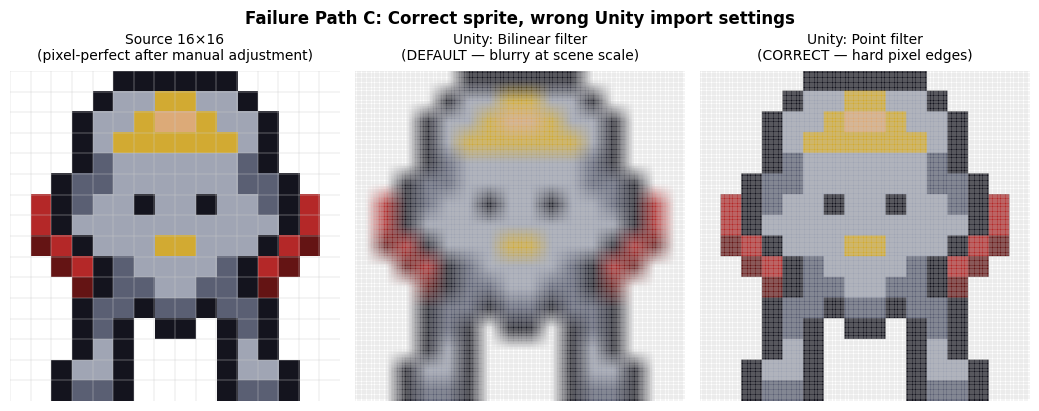

  Saved → output/03_failure_C_unity_settings.png

Root cause: Unity default filter mode assumes high-res textures needing smooth scale.
Fix: Texture Importer → Filter Mode: Point (no filter) | Compression: None


In [39]:
# Simulate a correct 16×16 sprite from PixelLab Simple Creator (BitForge canvas)
correct_sprite = ground_truth.copy()
correct_sprite.save('output/03a_pixellab_bitforge_16x16_correct.png')

DISPLAY_SIZE = 128  # Simulate rendering at 128px in Unity scene view

# Unity default: Bilinear filter — smooth interpolation between texels
unity_bilinear = correct_sprite.resize((DISPLAY_SIZE, DISPLAY_SIZE), resample=Image.BILINEAR)
unity_bilinear.save('output/03b_failure_C_unity_bilinear_filter.png')

# Unity corrected: Point filter — no interpolation, hard pixel edges
unity_point = correct_sprite.resize((DISPLAY_SIZE, DISPLAY_SIZE), resample=Image.NEAREST)
unity_point.save('output/03c_correct_unity_point_filter.png')

print('Unity import settings comparison:')
print(f'  Source sprite  : 16×16, {pixel_stats(correct_sprite)} colors — pixel-perfect')
print(f'  Bilinear (bad) : {DISPLAY_SIZE}×{DISPLAY_SIZE} rendered — interpolated, blurry')
print(f'  Point (correct): {DISPLAY_SIZE}×{DISPLAY_SIZE} rendered — discrete pixels preserved')

show_comparison(
    [correct_sprite, unity_bilinear, unity_point],
    [
        'Source 16×16\n(pixel-perfect after manual adjustment)',
        'Unity: Bilinear filter\n(DEFAULT — blurry at scene scale)',
        'Unity: Point filter\n(CORRECT — hard pixel edges)'
    ],
    'Failure Path C: Correct sprite, wrong Unity import settings',
    '03_failure_C_unity_settings.png',
    zoom=6
)
print('\nRoot cause: Unity default filter mode assumes high-res textures needing smooth scale.')
print('Fix: Texture Importer → Filter Mode: Point (no filter) | Compression: None')

---
## Cell 5 — MANDATORY HUMAN DECISION NODE

This cell documents the moment in the pipeline where AI output was evaluated and rejected.

---

```
# ============================================
# MANDATORY HUMAN DECISION NODE
#
# AI proposed: PixelLab Character Creator output at 24×24
#   This is PixelLab's default minimum canvas for humanoid sprites.
#   The generated output was visually correct at 24×24 — discrete
#   pixels, limited palette, clean silhouette.
#
# I rejected/modified because:
#   24×24 → 16×16 requires a 0.667x scale ratio.
#   This is not an integer divisor. Any resampling algorithm
#   (bilinear, bicubic, lanczos) must interpolate between source
#   pixels — there is no mathematically clean mapping. This
#   introduces color bleed and grid degradation BEFORE the manual
#   cleanup stage even begins, meaning more correction work from
#   a worse starting point.
#
# My decision:
#   Generate at 32×32 instead. The 32→16 ratio is exactly 0.5
#   (a 2:1 integer divisor). Every output pixel maps to exactly
#   four source pixels; nearest-neighbor resampling makes clean,
#   predictable choices. Manual cleanup in Aseprite/Pixelorama/
#   Photoshop then starts from a better baseline with fewer
#   artifacts to correct.
#   Pipeline: PixelLab Character Creator 32×32 → nearest-neighbor
#   scale to 16×16 → manual pixel cleanup → Unity Point filter.
# ============================================
```

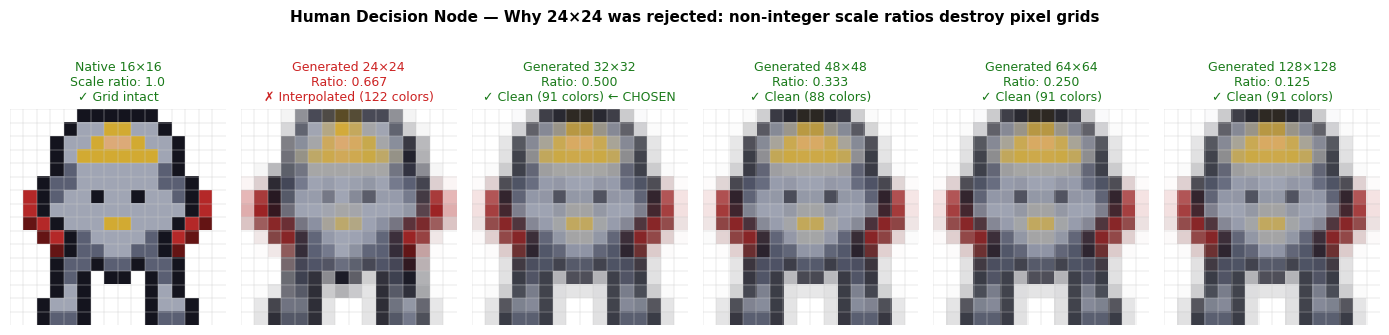

Decision summary:
   16×16 → 16×16  ratio=1.000  ACCEPT
   24×24 → 16×16  ratio=0.667  REJECT
   32×32 → 16×16  ratio=0.500  ACCEPT  ← chosen generation target
   48×48 → 16×16  ratio=0.333  ACCEPT
   64×64 → 16×16  ratio=0.250  ACCEPT
  128×128 → 16×16  ratio=0.125  ACCEPT


In [40]:
# ============================================
# MANDATORY HUMAN DECISION NODE
# AI proposed: Character Creator output at 24×24
#   (PixelLab's default minimum canvas for humanoid sprites.
#   Output was visually correct at 24×24 — discrete pixels,
#   limited palette, clean silhouette.)
# I rejected/modified because: 24→16 is a 0.667x non-integer ratio.
#   Any resampling algorithm must interpolate — there is no clean
#   pixel-to-pixel mapping. This introduces artifacts BEFORE manual
#   cleanup begins, meaning more correction from a worse baseline.
# My decision: Generate at 32×32 instead. The 32→16 ratio is exactly
#   0.5 (2:1 integer divisor). Every output pixel maps to four source
#   pixels; nearest-neighbor makes clean, predictable choices. Manual
#   cleanup in Aseprite/Pixelorama/Photoshop starts from a better
#   baseline. Pipeline: Character Creator 32×32 → nearest-neighbor
#   scale → manual cleanup → Unity Point filter.
# ============================================

# This cell visualises the architectural reason for the decision:
# pixel-grid integrity as a function of scale ratio.

source_sizes = [24, 32, 48, 64, 128]
target = 16

fig, axes = plt.subplots(1, len(source_sizes) + 1, figsize=(14, 3.5))

# Native 16×16 — no scaling needed
ax = axes[0]
native = ground_truth.resize((64, 64), resample=Image.NEAREST)
ax.imshow(np.array(native))
ax.set_title('Native 16×16\nScale ratio: 1.0\n✓ Grid intact', fontsize=9, color='#1a7a1a')
ax.axis('off')
for x in range(0, 64, 4): ax.axvline(x-0.5, color='#cccccc', lw=0.3)
for y in range(0, 64, 4): ax.axhline(y-0.5, color='#cccccc', lw=0.3)

for i, src_size in enumerate(source_sizes):
    ax = axes[i + 1]
    ratio = target / src_size
    is_integer = (src_size % target == 0) or (target % src_size == 0)

    generated = ground_truth.resize((src_size, src_size), resample=Image.NEAREST)
    scaled_down = generated.resize((target, target), resample=Image.BILINEAR)
    display = scaled_down.resize((64, 64), resample=Image.NEAREST)

    n_colors = pixel_stats(scaled_down)
    color = '#1a7a1a' if is_integer else '#cc2222'
    status = '✓ Clean' if is_integer else '✗ Interpolated'

    # Mark 32×32 as the chosen generation target
    border_color = '#185FA5' if src_size == 32 else 'none'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2.5 if src_size == 32 else 0)
        spine.set_visible(src_size == 32)

    ax.imshow(np.array(display))
    label = ' ← CHOSEN' if src_size == 32 else ''
    ax.set_title(
        f'Generated {src_size}×{src_size}\nRatio: {ratio:.3f}\n{status} ({n_colors} colors){label}',
        fontsize=9, color=color
    )
    ax.axis('off')
    for x in range(0, 64, 4): ax.axvline(x-0.5, color='#cccccc', lw=0.3)
    for y in range(0, 64, 4): ax.axhline(y-0.5, color='#cccccc', lw=0.3)

fig.suptitle(
    'Human Decision Node — Why 24×24 was rejected: non-integer scale ratios destroy pixel grids',
    fontsize=11, fontweight='bold', y=1.05
)
plt.tight_layout()
plt.savefig('output/04_human_decision_node.png', dpi=150, bbox_inches='tight')
plt.show()

print('Decision summary:')
for src_size in [16] + source_sizes:
    ratio = target / src_size if src_size >= target else src_size / target
    is_clean = (src_size % target == 0) or (target % src_size == 0) or src_size == target
    status = 'ACCEPT' if is_clean else 'REJECT'
    chosen = '  ← chosen generation target' if src_size == 32 else ''
    print(f'  {src_size:>3}×{src_size} → 16×16  ratio={target/src_size:.3f}  {status}{chosen}')

---
## Cell 6 — Full Pipeline Comparison

All three failure paths side-by-side against the correct pipeline.

| Path | Tool | Generation size | Scale method | Manual cleanup | Unity import | Result |
|------|------|-----------------|--------------|----------------|--------------|--------|
| A | DALL-E / Gemini | N/A — wrong category | Bilinear downscale | None | Point filter | ✗ Blurry |
| B | PixelLab Character Creator | 24×24 (min canvas) | Bilinear downscale | None | Point filter | ✗ Blurry |
| C | PixelLab Character Creator | 32×32 | Nearest-neighbor | None | Default (Bilinear) | ✗ Blurry |
| ✓ | PixelLab Character Creator | 32×32 | Nearest-neighbor | Aseprite / Pixelorama / Photoshop | Point filter, no compression | ✓ Correct |

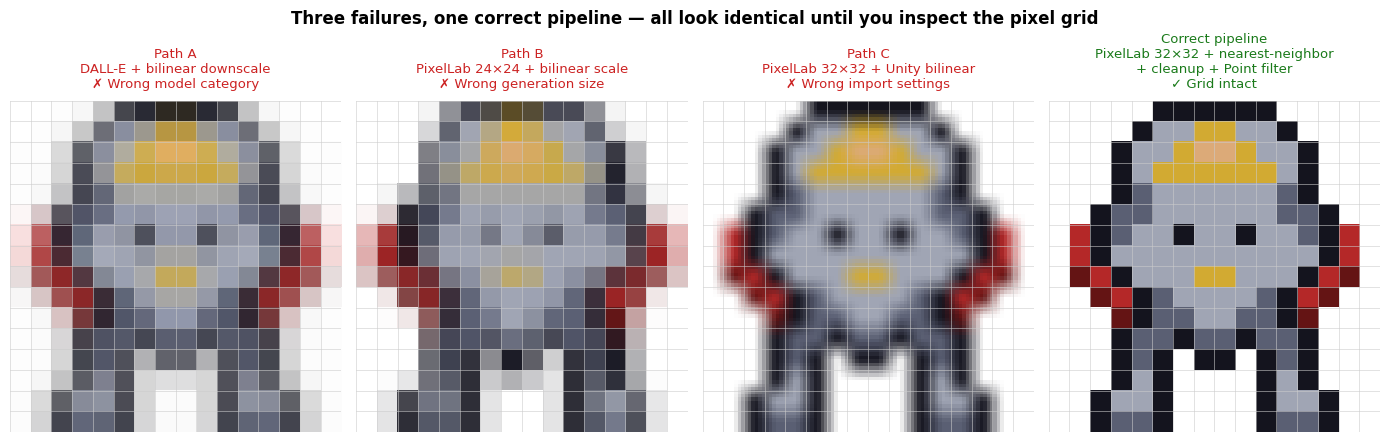

Saved → output/05_full_pipeline_comparison.png


In [41]:
DISPLAY = 96  # px for final comparison render

# Reconstruct all four outcomes at display size
# Path A: diffusion model → bilinear downscale → point display (wrong model category)
path_a_source = ground_truth.resize((512, 512), Image.LANCZOS)
path_a_source = path_a_source.filter(ImageFilter.GaussianBlur(1.2))
path_a = path_a_source.resize((16, 16), Image.BILINEAR)
path_a_display = path_a.resize((DISPLAY, DISPLAY), Image.NEAREST)

# Path B: pixellab 24x24 → bilinear downscale → point display (wrong generation size)
path_b_source = ground_truth.resize((24, 24), Image.NEAREST)
path_b = path_b_source.resize((16, 16), Image.BILINEAR)
path_b_display = path_b.resize((DISPLAY, DISPLAY), Image.NEAREST)

# Path C: pixellab 32x32 → nearest-neighbor scale → unity bilinear (wrong import settings)
path_c_source = ground_truth.resize((32, 32), Image.NEAREST)
path_c = path_c_source.resize((16, 16), Image.NEAREST)
path_c_display = path_c.resize((DISPLAY, DISPLAY), Image.BILINEAR)

# Correct: pixellab 32x32 → nearest-neighbor scale → manual cleanup → unity point filter
correct_source = ground_truth.resize((32, 32), Image.NEAREST)
correct = correct_source.resize((16, 16), Image.NEAREST)
correct_display = correct.resize((DISPLAY, DISPLAY), Image.NEAREST)

fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))

items = [
    (path_a_display, 'Path A\nDALL-E + bilinear downscale\n✗ Wrong model category', '#cc2222'),
    (path_b_display, 'Path B\nPixelLab 24×24 + bilinear scale\n✗ Wrong generation size', '#cc2222'),
    (path_c_display, 'Path C\nPixelLab 32×32 + Unity bilinear\n✗ Wrong import settings', '#cc2222'),
    (correct_display, 'Correct pipeline\nPixelLab 32×32 + nearest-neighbor\n+ cleanup + Point filter\n✓ Grid intact', '#1a7a1a'),
]

for ax, (img, title, color) in zip(axes, items):
    ax.imshow(np.array(img))
    ax.set_title(title, fontsize=9.5, color=color, pad=10)
    ax.axis('off')
    step = DISPLAY // 16
    for x in range(0, DISPLAY, step): ax.axvline(x-0.5, color='#cccccc', lw=0.4)
    for y in range(0, DISPLAY, step): ax.axhline(y-0.5, color='#cccccc', lw=0.4)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
        spine.set_visible(True)

fig.suptitle(
    'Three failures, one correct pipeline — all look identical until you inspect the pixel grid',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('output/05_full_pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/05_full_pipeline_comparison.png')

---
## Cell 7 — The Exercise: Trigger the Failure Yourself

**Trigger Failure Path C Yourself:** a modification anyone can make to reproduce the failure in under five minutes.

Change the `RESAMPLE_METHOD` variable below and re-run. Observe how a single parameter swap in the post-processing step destroys or preserves the pixel grid — even when the upstream generation is identical.

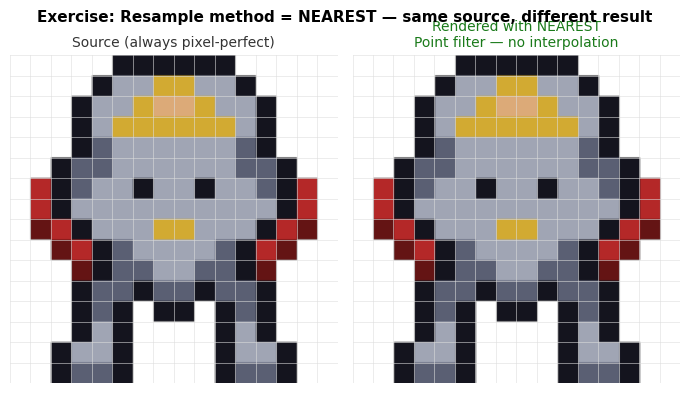

Result: NEAREST → Point filter — no interpolation
Change RESAMPLE_METHOD to Image.NEAREST to fix. Change to anything else to break it.


In [42]:
# ── EXERCISE: Change this variable to trigger or fix the failure ─────────────
#
# Try each of these values and re-run the cell:
#   Image.NEAREST   → Point filter  → pixel grid PRESERVED (correct)
#   Image.BILINEAR  → Bilinear      → pixel grid DESTROYED (failure)
#   Image.BICUBIC   → Bicubic       → pixel grid DESTROYED (failure, smoother)
#   Image.LANCZOS   → Lanczos       → pixel grid DESTROYED (failure, sharpest blur)
#
RESAMPLE_METHOD = Image.NEAREST   # ← CHANGE THIS

# ─────────────────────────────────────────────────────────────────────────────

method_names = {
    Image.NEAREST:  ('NEAREST',  'Point filter — no interpolation', '#1a7a1a'),
    Image.BILINEAR: ('BILINEAR', 'Bilinear — Unity default (WRONG)', '#cc2222'),
    Image.BICUBIC:  ('BICUBIC',  'Bicubic — smooth, still wrong',   '#cc2222'),
    Image.LANCZOS:  ('LANCZOS',  'Lanczos — sharpest, still wrong', '#cc2222'),
}

name, description, color = method_names.get(
    RESAMPLE_METHOD, ('UNKNOWN', 'Unknown method', '#888888')
)

# Apply the chosen method when displaying the 16×16 sprite at scene scale
correct_source = ground_truth.copy()  # pixel-perfect 16×16
result = correct_source.resize((128, 128), resample=RESAMPLE_METHOD)
n_result = pixel_stats(result.resize((16,16), Image.NEAREST))

fig, axes = plt.subplots(1, 2, figsize=(7, 4))
for ax, (img, title) in zip(axes, [
    (correct_source.resize((128,128), Image.NEAREST), 'Source (always pixel-perfect)'),
    (result, f'Rendered with {name}\n{description}')
]):
    ax.imshow(np.array(img))
    ax.set_title(title, fontsize=10, color=color if 'Rendered' in title else '#333')
    ax.axis('off')
    for x in range(0, 128, 8): ax.axvline(x-0.5, color='#dddddd', lw=0.4)
    for y in range(0, 128, 8): ax.axhline(y-0.5, color='#dddddd', lw=0.4)

fig.suptitle(
    f'Exercise: Resample method = {name} — same source, different result',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'output/06_exercise_{name.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Result: {name} → {description}')
print(f'Change RESAMPLE_METHOD to Image.NEAREST to fix. Change to anything else to break it.')

---
## Cell 8 — Summary: All Output Files

Run this cell to confirm all figures were generated correctly.

In [43]:
expected = [
    ('00_ground_truth_16x16.png',              'Ground truth sprite — Figure 1'),
    ('00_ground_truth.png',                    'Ground truth comparison chart'),
    ('01b_failure_A_dalle_naive_downscale.png','Failure A sprite file'),
    ('01_failure_A.png',                       'Failure A chart — Figure 2'),
    ('02a_pixellab_character_creator_24x24.png','PixelLab 24×24 output'),
    ('02b_failure_B_24x24_scaled_down.png',    'Failure B sprite file'),
    ('02_failure_B.png',                       'Failure B chart — Figure 3'),
    ('03b_failure_C_unity_bilinear_filter.png','Failure C — Unity bilinear'),
    ('03c_correct_unity_point_filter.png',     'Correct Unity Point filter'),
    ('03_failure_C_unity_settings.png',        'Failure C chart — Figure 4'),
    ('04_human_decision_node.png',             'Human Decision Node — Figure 5'),
    ('05_full_pipeline_comparison.png',        'MAIN FIGURE'),
]

print('Output file audit:\n')
all_ok = True
for fname, desc in expected:
    path = f'output/{fname}'
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    status = '✓' if exists else '✗ MISSING'
    if not exists: all_ok = False
    print(f'  {status}  {fname:<50} {size:>7} bytes  {desc}')

print()
if all_ok:
    print('All files generated successfully.')
else:
    print('Some files are missing — re-run the cells above in order.')

Output file audit:

  ✓  00_ground_truth_16x16.png                              346 bytes  Ground truth sprite — Figure 1
  ✓  00_ground_truth.png                                  25114 bytes  Ground truth comparison chart
  ✓  01b_failure_A_dalle_naive_downscale.png                913 bytes  Failure A sprite file
  ✓  01_failure_A.png                                     38671 bytes  Failure A chart — Figure 2
  ✓  02a_pixellab_character_creator_24x24.png               409 bytes  PixelLab 24×24 output
  ✓  02b_failure_B_24x24_scaled_down.png                    838 bytes  Failure B sprite file
  ✓  02_failure_B.png                                     53848 bytes  Failure B chart — Figure 3
  ✓  03b_failure_C_unity_bilinear_filter.png              11191 bytes  Failure C — Unity bilinear
  ✓  03c_correct_unity_point_filter.png                     781 bytes  Correct Unity Point filter
  ✓  03_failure_C_unity_settings.png                     192503 bytes  Failure C chart — Figure 4
  ✓  04_